# Phase 2: Visual Contrastive Decoding (VCD)

Pivot model: Qwen2.5-VL-7B-Instruct. Pilot on Animals + Chess Pieces.

## Setup

In [8]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from datasets import load_dataset
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor

In [9]:
MODEL_ID = "Qwen/Qwen2.5-VL-7B-Instruct"

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
)
model.eval()
print("Model loaded")

preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

Model loaded


In [10]:
def add_gaussian_noise(image: Image.Image, sigma: float = 75.0, seed: int | None = None) -> Image.Image:
    """
    Add Gaussian noise to a PIL image in pixel space.

    Args:
        image: PIL image (RGB).
        sigma: standard deviation of the noise on 0-255 scale.
        seed: optional seed for reproducibility.

    Returns:
        PIL image with noise applied.
    """
    rng = np.random.default_rng(seed)
    arr = np.asarray(image.convert("RGB"), dtype=np.float32)
    noise = rng.normal(loc=0.0, scale=sigma, size=arr.shape)
    noisy = np.clip(arr + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(noisy)

### Step 2: Visual sanity check

Render one sample as real vs noisy. Confirm the noise is clearly visible but the image is still recognizable.

In [4]:
ds = load_dataset("anvo25/vlms-are-biased", split="main")
animal_samples = [s for s in ds if s.get("topic") == "Animals"]
print(f"Loaded {len(animal_samples)} animal samples")
print(f"Columns: {list(animal_samples[0].keys())}")

Loaded 546 animal samples
Columns: ['image', 'ID', 'image_path', 'topic', 'sub_topic', 'prompt', 'ground_truth', 'expected_bias', 'with_title', 'type_of_question', 'pixel', 'metadata']


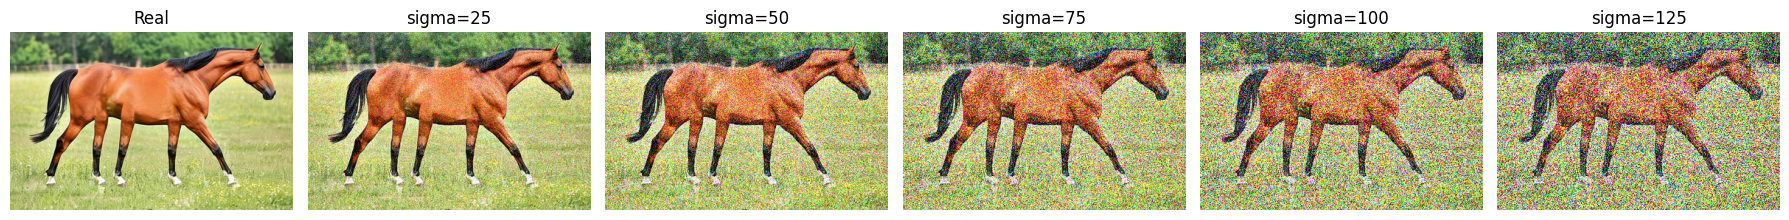

In [11]:
sample = animal_samples[0]
real_img = sample["image"].convert("RGB")

sigmas = [25, 50, 75, 100, 125]

fig, axes = plt.subplots(1, len(sigmas) + 1, figsize=(3 * (len(sigmas) + 1), 4))
axes[0].imshow(real_img)
axes[0].set_title("Real")
axes[0].axis("off")

for ax, s in zip(axes[1:], sigmas):
    ax.imshow(add_gaussian_noise(real_img, sigma=s, seed=0))
    ax.set_title(f"sigma={s}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Step 3: VCD scoring wrapper

For each candidate answer, score on real and noisy image. Combine into a contrastive log-probability:

contrastive_lp = (1 + alpha) * real_lp - alpha * noisy_lp

We keep the real and noisy components separate in the output so we can recompute any alpha post-hoc without rerunning the model.

In [12]:
def score_sequence(image, prompt, answer):
    """Score a candidate answer by computing its sequence logprob."""
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": prompt}
        ]
    }]
    prompt_text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    full_text = prompt_text + str(answer)

    prompt_inputs = processor(text=[prompt_text], images=[image], return_tensors="pt")
    prompt_len = prompt_inputs["input_ids"].shape[1]

    inputs = processor(text=[full_text], images=[image], return_tensors="pt").to("cuda")
    inputs["pixel_values"] = inputs["pixel_values"].to(torch.float16)

    with torch.no_grad():
        outputs = model(**inputs)

    log_probs = torch.log_softmax(outputs.logits, dim=-1)
    answer_ids = inputs["input_ids"][0, prompt_len:]

    per_tok_lp, entropies = [], []
    for i, tok_id in enumerate(answer_ids):
        pos = prompt_len - 1 + i
        per_tok_lp.append(log_probs[0, pos, tok_id].item())
        d = log_probs[0, pos]
        entropies.append(-(d.exp() * d).sum().item())

    return {
        "seq_logprob": sum(per_tok_lp),
        "avg_logprob": sum(per_tok_lp) / len(per_tok_lp),
        "entropy_step1": entropies[0],
        "entropy_mean": sum(entropies) / len(entropies),
        "n_tokens": len(answer_ids),
    }

In [13]:
def score_sequence_vcd(image, noisy_image, prompt, answer):
    """Score an answer on both real and noisy image. Alpha is applied later."""
    real = score_sequence(image, prompt, answer)
    noisy = score_sequence(noisy_image, prompt, answer)
    return {
        "real_seq_logprob": real["seq_logprob"],
        "real_avg_logprob": real["avg_logprob"],
        "real_entropy_step1": real["entropy_step1"],
        "real_entropy_mean": real["entropy_mean"],
        "noisy_seq_logprob": noisy["seq_logprob"],
        "noisy_avg_logprob": noisy["avg_logprob"],
        "noisy_entropy_step1": noisy["entropy_step1"],
        "noisy_entropy_mean": noisy["entropy_mean"],
        "n_tokens": real["n_tokens"],
    }


def analyze_sample_vcd(sample, sigma, seed=0):
    """VCD analysis for one sample. Returns raw real/noisy logprobs for both candidates."""
    gt = str(sample["ground_truth"])
    bias = str(sample["expected_bias"])
    real_img = sample["image"].convert("RGB")
    noisy_img = add_gaussian_noise(real_img, sigma=sigma, seed=seed)

    gold = score_sequence_vcd(real_img, noisy_img, sample["prompt"], gt)
    biased = score_sequence_vcd(real_img, noisy_img, sample["prompt"], bias)

    return {
        "topic": sample["topic"],
        "question_type": sample["type_of_question"],
        "ground_truth": gt,
        "expected_bias": bias,
        "sigma": sigma,
        # Gold candidate, real and noisy
        "gold_real_seq_logprob": gold["real_seq_logprob"],
        "gold_real_avg_logprob": gold["real_avg_logprob"],
        "gold_noisy_seq_logprob": gold["noisy_seq_logprob"],
        "gold_noisy_avg_logprob": gold["noisy_avg_logprob"],
        "gold_real_entropy_step1": gold["real_entropy_step1"],
        "gold_noisy_entropy_step1": gold["noisy_entropy_step1"],
        "gold_n_tokens": gold["n_tokens"],
        # Bias candidate, real and noisy
        "bias_real_seq_logprob": biased["real_seq_logprob"],
        "bias_real_avg_logprob": biased["real_avg_logprob"],
        "bias_noisy_seq_logprob": biased["noisy_seq_logprob"],
        "bias_noisy_avg_logprob": biased["noisy_avg_logprob"],
        "bias_real_entropy_step1": biased["real_entropy_step1"],
        "bias_noisy_entropy_step1": biased["noisy_entropy_step1"],
        "bias_n_tokens": biased["n_tokens"],
        "same_length": gold["n_tokens"] == biased["n_tokens"],
    }

### Step 4: Single-sample sanity check

Run VCD on one Animals sample at sigma=75. Confirm:
- Real log-probs roughly match what we saw in Phase 1
- Noisy log-probs collapse toward the bias token
- No tensor shape or device errors before scaling up

In [15]:
test_sample = animal_samples[0]
result = analyze_sample_vcd(test_sample, sigma=75, seed=0)

# Show as a tidy dataframe
df = pd.DataFrame([result])
print(df.T)

# Quick sanity computation: alpha=1.0 contrastive avg_logprob
alpha = 1.0
gold_contrastive = (1 + alpha) * result["gold_real_avg_logprob"] - alpha * result["gold_noisy_avg_logprob"]
bias_contrastive = (1 + alpha) * result["bias_real_avg_logprob"] - alpha * result["bias_noisy_avg_logprob"]

print(f"\nGround truth: {result['ground_truth']}, Bias: {result['expected_bias']}")
print(f"Real avg_margin (gold - bias):       {result['gold_real_avg_logprob'] - result['bias_real_avg_logprob']:+.4f}")
print(f"Noisy avg_margin (gold - bias):      {result['gold_noisy_avg_logprob'] - result['bias_noisy_avg_logprob']:+.4f}")
print(f"Contrastive avg_margin (alpha=1.0):  {gold_contrastive - bias_contrastive:+.4f}")

                                  0
topic                       Animals
question_type                    Q1
ground_truth                      5
expected_bias                     4
sigma                            75
gold_real_seq_logprob     -18.71875
gold_real_avg_logprob     -18.71875
gold_noisy_seq_logprob   -19.921875
gold_noisy_avg_logprob   -19.921875
gold_real_entropy_step1    0.009476
gold_noisy_entropy_step1   0.008797
gold_n_tokens                     1
bias_real_seq_logprob       -8.0625
bias_real_avg_logprob       -8.0625
bias_noisy_seq_logprob    -9.515625
bias_noisy_avg_logprob    -9.515625
bias_real_entropy_step1    0.009476
bias_noisy_entropy_step1   0.008797
bias_n_tokens                     1
same_length                    True

Ground truth: 5, Bias: 4
Real avg_margin (gold - bias):       -10.6562
Noisy avg_margin (gold - bias):      -10.4062
Contrastive avg_margin (alpha=1.0):  -10.9062


### Step 5: Pilot on 20 Animals samples

Run VCD at sigma=75 and sigma=100. Aggregate the real vs noisy margin shift to check whether the noisy run actually pulls toward the bias token (which is what VCD needs).

In [16]:
from tqdm import tqdm

PILOT_N = 20
SIGMAS = [75, 100]

records = []
for sigma in SIGMAS:
    for sample in tqdm(animal_samples[:PILOT_N], desc=f"sigma={sigma}"):
        try:
            records.append(analyze_sample_vcd(sample, sigma=sigma, seed=0))
        except Exception as e:
            print(f"Failed on sample: {e}")

pilot_df = pd.DataFrame(records)

# Margins
pilot_df["real_avg_margin"] = pilot_df["gold_real_avg_logprob"] - pilot_df["bias_real_avg_logprob"]
pilot_df["noisy_avg_margin"] = pilot_df["gold_noisy_avg_logprob"] - pilot_df["bias_noisy_avg_logprob"]
pilot_df["margin_shift"] = pilot_df["noisy_avg_margin"] - pilot_df["real_avg_margin"]

# VCD contrastive margin at a few alpha values
for alpha in [0.5, 1.0, 2.0]:
    gold_c = (1 + alpha) * pilot_df["gold_real_avg_logprob"] - alpha * pilot_df["gold_noisy_avg_logprob"]
    bias_c = (1 + alpha) * pilot_df["bias_real_avg_logprob"] - alpha * pilot_df["bias_noisy_avg_logprob"]
    pilot_df[f"vcd_margin_a{alpha}"] = gold_c - bias_c

# Aggregate per sigma
print("=== Mean margins per sigma ===")
agg = pilot_df.groupby("sigma").agg(
    real_margin=("real_avg_margin", "mean"),
    noisy_margin=("noisy_avg_margin", "mean"),
    margin_shift=("margin_shift", "mean"),
    vcd_a05=("vcd_margin_a0.5", "mean"),
    vcd_a1=("vcd_margin_a1.0", "mean"),
    vcd_a2=("vcd_margin_a2.0", "mean"),
).round(3)
print(agg)

# % prefers gold (margin > 0)
print("\n=== % prefers gold (margin > 0) ===")
prefers = pilot_df.groupby("sigma").agg(
    real=("real_avg_margin", lambda x: (x > 0).mean() * 100),
    noisy=("noisy_avg_margin", lambda x: (x > 0).mean() * 100),
    vcd_a05=("vcd_margin_a0.5", lambda x: (x > 0).mean() * 100),
    vcd_a1=("vcd_margin_a1.0", lambda x: (x > 0).mean() * 100),
    vcd_a2=("vcd_margin_a2.0", lambda x: (x > 0).mean() * 100),
).round(1)
print(prefers)

sigma=100: 100%|███████████████████████████████████████████████████████████████| 20/20 [00:34<00:00,  1.73s/it]

=== Mean margins per sigma ===
       real_margin  noisy_margin  margin_shift  vcd_a05  vcd_a1  vcd_a2
sigma                                                                  
75          -9.932        -9.834         0.097    -9.98 -10.029 -10.126
100         -9.932        -9.714         0.218   -10.04 -10.149 -10.367

=== % prefers gold (margin > 0) ===
       real  noisy  vcd_a05  vcd_a1  vcd_a2
sigma                                      
75      0.0    0.0      0.0     0.0     0.0
100     0.0    0.0      0.0     0.0     0.0


In [17]:
patterned_samples = [s for s in ds if s.get("topic") == "Patterned Grid"]
print(f"Loaded {len(patterned_samples)} Patterned Grid samples")

PILOT_N = 20
SIGMAS = [75, 100]

records = []
for sigma in SIGMAS:
    for sample in tqdm(patterned_samples[:PILOT_N], desc=f"sigma={sigma}"):
        try:
            records.append(analyze_sample_vcd(sample, sigma=sigma, seed=0))
        except Exception as e:
            print(f"Failed on sample: {e}")

pg_df = pd.DataFrame(records)

pg_df["real_avg_margin"] = pg_df["gold_real_avg_logprob"] - pg_df["bias_real_avg_logprob"]
pg_df["noisy_avg_margin"] = pg_df["gold_noisy_avg_logprob"] - pg_df["bias_noisy_avg_logprob"]
pg_df["margin_shift"] = pg_df["noisy_avg_margin"] - pg_df["real_avg_margin"]

for alpha in [0.5, 1.0, 2.0]:
    gold_c = (1 + alpha) * pg_df["gold_real_avg_logprob"] - alpha * pg_df["gold_noisy_avg_logprob"]
    bias_c = (1 + alpha) * pg_df["bias_real_avg_logprob"] - alpha * pg_df["bias_noisy_avg_logprob"]
    pg_df[f"vcd_margin_a{alpha}"] = gold_c - bias_c

print("=== Mean margins per sigma (Patterned Grid) ===")
agg = pg_df.groupby("sigma").agg(
    real_margin=("real_avg_margin", "mean"),
    noisy_margin=("noisy_avg_margin", "mean"),
    margin_shift=("margin_shift", "mean"),
    vcd_a05=("vcd_margin_a0.5", "mean"),
    vcd_a1=("vcd_margin_a1.0", "mean"),
    vcd_a2=("vcd_margin_a2.0", "mean"),
).round(3)
print(agg)

print("\n=== % prefers gold (Patterned Grid) ===")
prefers = pg_df.groupby("sigma").agg(
    real=("real_avg_margin", lambda x: (x > 0).mean() * 100),
    noisy=("noisy_avg_margin", lambda x: (x > 0).mean() * 100),
    vcd_a05=("vcd_margin_a0.5", lambda x: (x > 0).mean() * 100),
    vcd_a1=("vcd_margin_a1.0", lambda x: (x > 0).mean() * 100),
    vcd_a2=("vcd_margin_a2.0", lambda x: (x > 0).mean() * 100),
).round(1)
print(prefers)

Loaded 336 Patterned Grid samples


sigma=100: 100%|███████████████████████████████████████████████████████████████| 20/20 [00:47<00:00,  2.36s/it]

=== Mean margins per sigma (Patterned Grid) ===
       real_margin  noisy_margin  margin_shift  vcd_a05  vcd_a1  vcd_a2
sigma                                                                  
75          -2.163        -1.715         0.448   -2.387  -2.611  -3.059
100         -2.163        -1.602         0.561   -2.444  -2.724  -3.285

=== % prefers gold (Patterned Grid) ===
       real  noisy  vcd_a05  vcd_a1  vcd_a2
sigma                                      
75      5.0    0.0     10.0    10.0    10.0
100     5.0    0.0     10.0    10.0    10.0


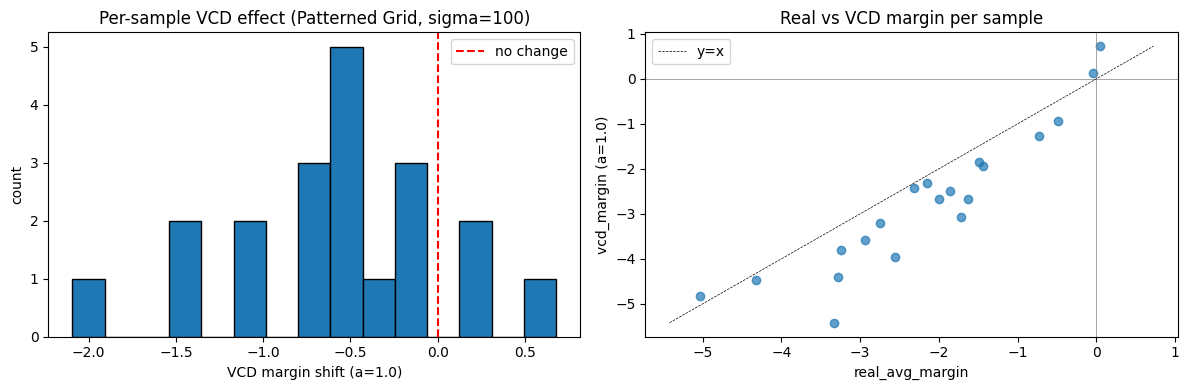


Samples that crossed threshold (real <= 0, vcd > 0): 1
Samples helped (vcd > real): 3
Samples hurt (vcd < real): 17

=== Threshold crossers ===
   question_type ground_truth expected_bias  real_avg_margin  noisy_avg_margin  vcd_margin_a1.0  gold_n_tokens  bias_n_tokens
39            Q2            2             3        -0.039062          -0.21875         0.140625              1              1

=== Most helped (top 3 by vcd_shift) ===
   question_type ground_truth expected_bias  real_avg_margin  vcd_margin_a1.0  vcd_shift_a1
38            Q1            2             3         0.046875         0.726562      0.679688
24            Q1            2             3        -5.039062        -4.828125      0.210938
39            Q2            2             3        -0.039062         0.140625      0.179688

=== Most hurt (bottom 3 by vcd_shift) ===
   question_type ground_truth expected_bias  real_avg_margin  vcd_margin_a1.0  vcd_shift_a1
20            Q1            2             3        -3.3281

In [18]:
# Use sigma=100 since the threshold-crossing effect was identical to sigma=75
sub = pg_df[pg_df["sigma"] == 100].copy()
sub["vcd_shift_a1"] = sub["vcd_margin_a1.0"] - sub["real_avg_margin"]
sub["crossed_threshold"] = (sub["real_avg_margin"] <= 0) & (sub["vcd_margin_a1.0"] > 0)

# 1. Distribution of VCD effect per sample
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(sub["vcd_shift_a1"], bins=15, edgecolor="black")
axes[0].axvline(0, color="red", linestyle="--", label="no change")
axes[0].set_xlabel("VCD margin shift (a=1.0)")
axes[0].set_ylabel("count")
axes[0].set_title("Per-sample VCD effect (Patterned Grid, sigma=100)")
axes[0].legend()

axes[1].scatter(sub["real_avg_margin"], sub["vcd_margin_a1.0"], alpha=0.7)
axes[1].axhline(0, color="gray", linewidth=0.5)
axes[1].axvline(0, color="gray", linewidth=0.5)
mn = min(sub["real_avg_margin"].min(), sub["vcd_margin_a1.0"].min())
mx = max(sub["real_avg_margin"].max(), sub["vcd_margin_a1.0"].max())
axes[1].plot([mn, mx], [mn, mx], "k--", linewidth=0.5, label="y=x")
axes[1].set_xlabel("real_avg_margin")
axes[1].set_ylabel("vcd_margin (a=1.0)")
axes[1].set_title("Real vs VCD margin per sample")
axes[1].legend()

plt.tight_layout()
plt.show()

# 2. Threshold crossers
print(f"\nSamples that crossed threshold (real <= 0, vcd > 0): {sub['crossed_threshold'].sum()}")
print(f"Samples helped (vcd > real): {(sub['vcd_shift_a1'] > 0).sum()}")
print(f"Samples hurt (vcd < real): {(sub['vcd_shift_a1'] < 0).sum()}")

print("\n=== Threshold crossers ===")
crossers = sub[sub["crossed_threshold"]]
if len(crossers) > 0:
    print(crossers[["question_type", "ground_truth", "expected_bias",
                    "real_avg_margin", "noisy_avg_margin", "vcd_margin_a1.0",
                    "gold_n_tokens", "bias_n_tokens"]].to_string())
else:
    print("None")

print("\n=== Most helped (top 3 by vcd_shift) ===")
print(sub.nlargest(3, "vcd_shift_a1")[["question_type", "ground_truth", "expected_bias",
                                        "real_avg_margin", "vcd_margin_a1.0", "vcd_shift_a1"]].to_string())

print("\n=== Most hurt (bottom 3 by vcd_shift) ===")
print(sub.nsmallest(3, "vcd_shift_a1")[["question_type", "ground_truth", "expected_bias",
                                         "real_avg_margin", "vcd_margin_a1.0", "vcd_shift_a1"]].to_string())

### Step 6: Diagnose why noise is not activating priors

If VCD is not working, the most likely cause is that the noisy run is not producing the "language prior" behavior VCD assumes. Check whether the noisy image actually changes what the model thinks, or whether the model is essentially ignoring the noise.

Key questions:
- Does the bias logprob change much between real and noisy?
- Does the gold logprob change much between real and noisy?
- If both barely change, the image (real or noisy) is not driving the answer at all. The model is prior-dominated regardless of what it sees.

=== Mean logprob shift from real to noisy (per domain x sigma) ===
Negative = answer became less likely with noise
Positive = answer became more likely with noise (suggests prior activation)

                      gold_shift  bias_shift  gold_real_lp  gold_noisy_lp  \
domain         sigma                                                        
Animals        75         -0.780      -0.877       -18.902        -19.681   
               100        -0.866      -1.083       -18.902        -19.767   
Patterned Grid 75          0.455       0.007       -12.855        -12.400   
               100        -0.068      -0.629       -12.855        -12.923   

                      bias_real_lp  bias_noisy_lp  
domain         sigma                               
Animals        75           -8.970         -9.847  
               100          -8.970        -10.053  
Patterned Grid 75          -10.692        -10.685  
               100         -10.692        -11.320  


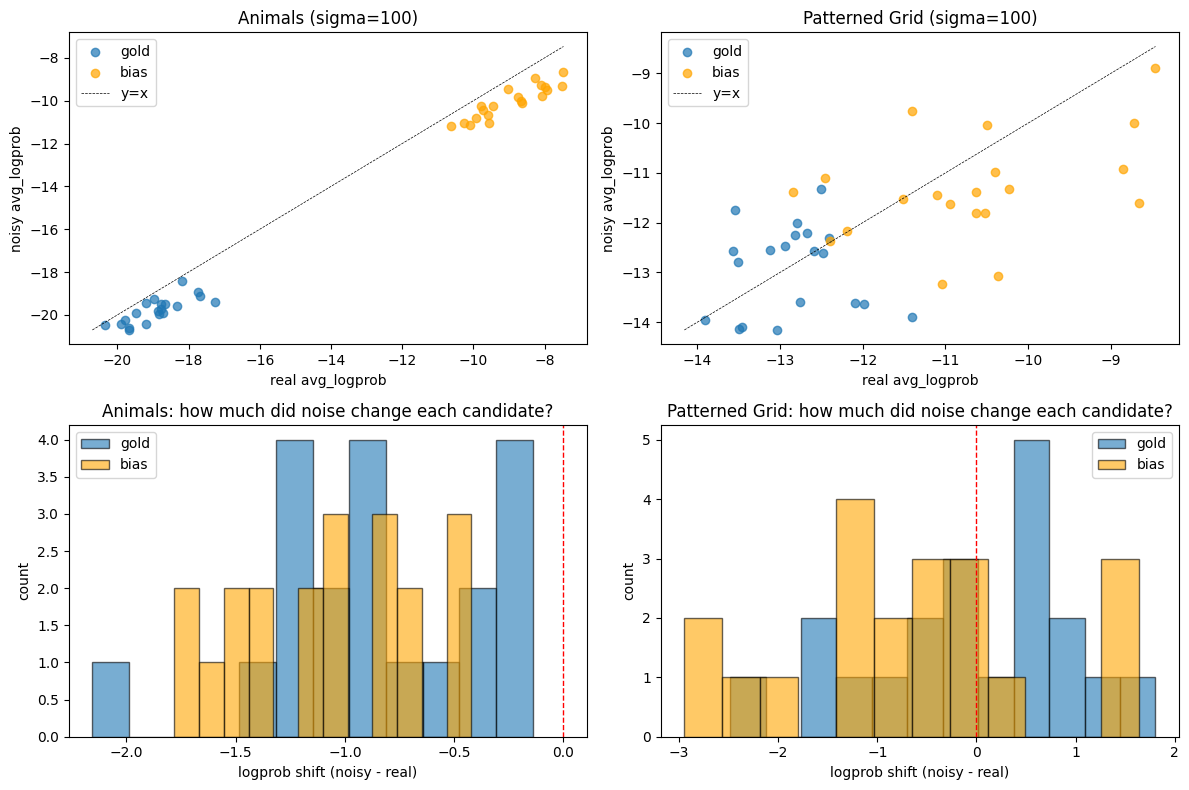

In [19]:
# Combine both pilots for more samples
all_pilots = pd.concat([
    pilot_df.assign(domain="Animals"),
    pg_df.assign(domain="Patterned Grid"),
], ignore_index=True)

# Compute logprob shifts (noisy - real) for each candidate
all_pilots["gold_lp_shift"] = all_pilots["gold_noisy_avg_logprob"] - all_pilots["gold_real_avg_logprob"]
all_pilots["bias_lp_shift"] = all_pilots["bias_noisy_avg_logprob"] - all_pilots["bias_real_avg_logprob"]

print("=== Mean logprob shift from real to noisy (per domain x sigma) ===")
print("Negative = answer became less likely with noise")
print("Positive = answer became more likely with noise (suggests prior activation)")
print()
shifts = all_pilots.groupby(["domain", "sigma"]).agg(
    gold_shift=("gold_lp_shift", "mean"),
    bias_shift=("bias_lp_shift", "mean"),
    gold_real_lp=("gold_real_avg_logprob", "mean"),
    gold_noisy_lp=("gold_noisy_avg_logprob", "mean"),
    bias_real_lp=("bias_real_avg_logprob", "mean"),
    bias_noisy_lp=("bias_noisy_avg_logprob", "mean"),
).round(3)
print(shifts)

# Quick visual: 4 panels
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
domains = ["Animals", "Patterned Grid"]

for col, domain in enumerate(domains):
    sub = all_pilots[(all_pilots["domain"] == domain) & (all_pilots["sigma"] == 100)]

    axes[0, col].scatter(sub["gold_real_avg_logprob"], sub["gold_noisy_avg_logprob"], label="gold", alpha=0.7)
    axes[0, col].scatter(sub["bias_real_avg_logprob"], sub["bias_noisy_avg_logprob"], label="bias", alpha=0.7, color="orange")
    mn = min(sub[["gold_real_avg_logprob", "bias_real_avg_logprob"]].min().min(),
             sub[["gold_noisy_avg_logprob", "bias_noisy_avg_logprob"]].min().min())
    mx = max(sub[["gold_real_avg_logprob", "bias_real_avg_logprob"]].max().max(),
             sub[["gold_noisy_avg_logprob", "bias_noisy_avg_logprob"]].max().max())
    axes[0, col].plot([mn, mx], [mn, mx], "k--", linewidth=0.5, label="y=x")
    axes[0, col].set_xlabel("real avg_logprob")
    axes[0, col].set_ylabel("noisy avg_logprob")
    axes[0, col].set_title(f"{domain} (sigma=100)")
    axes[0, col].legend()

    axes[1, col].hist(sub["gold_lp_shift"], bins=12, alpha=0.6, label="gold", edgecolor="black")
    axes[1, col].hist(sub["bias_lp_shift"], bins=12, alpha=0.6, label="bias", edgecolor="black", color="orange")
    axes[1, col].axvline(0, color="red", linestyle="--", linewidth=1)
    axes[1, col].set_xlabel("logprob shift (noisy - real)")
    axes[1, col].set_ylabel("count")
    axes[1, col].set_title(f"{domain}: how much did noise change each candidate?")
    axes[1, col].legend()

plt.tight_layout()
plt.show()

### Step 7: Token-step VCD

Apply VCD at generation time. At the answer-emission step:

1. Forward pass on the real image: get `logits_real`
2. Forward pass on the noisy image: get `logits_noisy`
3. Combine: `logits_vcd = (1 + alpha) * logits_real - alpha * logits_noisy`
4. Read the logprob of the gold and bias tokens from the combined distribution

Single-token answers only (we already filtered for these in Phase 1). Multi-token candidates would require a more involved generation loop.

In [20]:
def token_step_vcd(image, noisy_image, prompt, gold_token_str, bias_token_str, alpha=1.0):
    """
    Token-step VCD: combine logits from real and noisy image at the answer position,
    then read gold/bias logprobs from the contrastive distribution.

    Assumes single-token answers. Returns logprobs at the first emission step.
    """
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": prompt}
        ]
    }]
    prompt_text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    # Run forward pass on both images at the prompt-only position
    def get_last_logits(img):
        inputs = processor(text=[prompt_text], images=[img], return_tensors="pt").to("cuda")
        inputs["pixel_values"] = inputs["pixel_values"].to(torch.float16)
        with torch.no_grad():
            outputs = model(**inputs)
        # Last position predicts the next (answer) token
        return outputs.logits[0, -1, :]  # shape: [vocab]

    logits_real = get_last_logits(image)
    logits_noisy = get_last_logits(noisy_image)

    # Token IDs for gold and bias
    gold_id = processor.tokenizer.encode(str(gold_token_str), add_special_tokens=False)[0]
    bias_id = processor.tokenizer.encode(str(bias_token_str), add_special_tokens=False)[0]

    # Logprobs from each distribution
    lp_real = torch.log_softmax(logits_real.float(), dim=-1)
    lp_noisy = torch.log_softmax(logits_noisy.float(), dim=-1)

    # Contrastive logits, then logprobs
    logits_vcd = (1 + alpha) * logits_real.float() - alpha * logits_noisy.float()
    lp_vcd = torch.log_softmax(logits_vcd, dim=-1)

    # Entropy at this step (real and noisy and vcd)
    ent_real = -(lp_real.exp() * lp_real).sum().item()
    ent_noisy = -(lp_noisy.exp() * lp_noisy).sum().item()
    ent_vcd = -(lp_vcd.exp() * lp_vcd).sum().item()

    return {
        "gold_lp_real": lp_real[gold_id].item(),
        "bias_lp_real": lp_real[bias_id].item(),
        "gold_lp_noisy": lp_noisy[gold_id].item(),
        "bias_lp_noisy": lp_noisy[bias_id].item(),
        "gold_lp_vcd": lp_vcd[gold_id].item(),
        "bias_lp_vcd": lp_vcd[bias_id].item(),
        "entropy_real": ent_real,
        "entropy_noisy": ent_noisy,
        "entropy_vcd": ent_vcd,
        "alpha": alpha,
    }


def analyze_sample_token_vcd(sample, sigma, alpha=1.0, seed=0):
    real_img = sample["image"].convert("RGB")
    noisy_img = add_gaussian_noise(real_img, sigma=sigma, seed=seed)
    gt = str(sample["ground_truth"])
    bias = str(sample["expected_bias"])

    # Single-token check (skip otherwise)
    gt_ids = processor.tokenizer.encode(gt, add_special_tokens=False)
    bias_ids = processor.tokenizer.encode(bias, add_special_tokens=False)
    if len(gt_ids) != 1 or len(bias_ids) != 1:
        return None

    r = token_step_vcd(real_img, noisy_img, sample["prompt"], gt, bias, alpha=alpha)
    r["topic"] = sample["topic"]
    r["question_type"] = sample["type_of_question"]
    r["ground_truth"] = gt
    r["expected_bias"] = bias
    r["sigma"] = sigma
    r["margin_real"] = r["gold_lp_real"] - r["bias_lp_real"]
    r["margin_noisy"] = r["gold_lp_noisy"] - r["bias_lp_noisy"]
    r["margin_vcd"] = r["gold_lp_vcd"] - r["bias_lp_vcd"]
    return r

In [21]:
test = analyze_sample_token_vcd(animal_samples[0], sigma=100, alpha=1.0, seed=0)
if test is None:
    print("Skipped (multi-token answer)")
else:
    print(f"GT: {test['ground_truth']}, Bias: {test['expected_bias']}")
    print(f"Real:  gold_lp={test['gold_lp_real']:+.3f}, bias_lp={test['bias_lp_real']:+.3f}, margin={test['margin_real']:+.3f}, entropy={test['entropy_real']:.3f}")
    print(f"Noisy: gold_lp={test['gold_lp_noisy']:+.3f}, bias_lp={test['bias_lp_noisy']:+.3f}, margin={test['margin_noisy']:+.3f}, entropy={test['entropy_noisy']:.3f}")
    print(f"VCD:   gold_lp={test['gold_lp_vcd']:+.3f}, bias_lp={test['bias_lp_vcd']:+.3f}, margin={test['margin_vcd']:+.3f}, entropy={test['entropy_vcd']:.3f}")

GT: 5, Bias: 4
Real:  gold_lp=-18.712, bias_lp=-8.063, margin=-10.648, entropy=0.010
Noisy: gold_lp=-19.919, bias_lp=-9.782, margin=-10.137, entropy=0.010
VCD:   gold_lp=-17.506, bias_lp=-6.346, margin=-11.160, entropy=0.019


In [22]:
records = []
for sigma in [75, 100]:
    for sample in tqdm(animal_samples[:20], desc=f"Animals sigma={sigma}"):
        try:
            r = analyze_sample_token_vcd(sample, sigma=sigma, alpha=1.0, seed=0)
            if r is not None:
                r["domain"] = "Animals"
                records.append(r)
        except Exception as e:
            print(f"Failed: {e}")

    for sample in tqdm(patterned_samples[:20], desc=f"Patterned Grid sigma={sigma}"):
        try:
            r = analyze_sample_token_vcd(sample, sigma=sigma, alpha=1.0, seed=0)
            if r is not None:
                r["domain"] = "Patterned Grid"
                records.append(r)
        except Exception as e:
            print(f"Failed: {e}")

token_df = pd.DataFrame(records)

# Recompute VCD margins for multiple alphas (cheap, no extra forward passes since we have logits-based shifts already encoded in the lp values)
# Note: the alpha sweep here requires re-running token_step_vcd with different alpha.
# For now, just report alpha=1.0.

print("=== Token-step VCD: mean margins per domain x sigma (alpha=1.0) ===")
agg = token_df.groupby(["domain", "sigma"]).agg(
    real_margin=("margin_real", "mean"),
    noisy_margin=("margin_noisy", "mean"),
    vcd_margin=("margin_vcd", "mean"),
    margin_shift=("margin_noisy", lambda x: 0),  # placeholder
).round(3)
agg["margin_shift"] = (token_df.groupby(["domain", "sigma"])["margin_noisy"].mean()
                       - token_df.groupby(["domain", "sigma"])["margin_real"].mean()).round(3)
print(agg[["real_margin", "noisy_margin", "margin_shift", "vcd_margin"]])

print("\n=== % prefers gold ===")
prefers = token_df.groupby(["domain", "sigma"]).agg(
    real=("margin_real", lambda x: (x > 0).mean() * 100),
    noisy=("margin_noisy", lambda x: (x > 0).mean() * 100),
    vcd=("margin_vcd", lambda x: (x > 0).mean() * 100),
).round(1)
print(prefers)

print("\n=== Entropy: real vs noisy vs vcd ===")
ent = token_df.groupby(["domain", "sigma"]).agg(
    ent_real=("entropy_real", "mean"),
    ent_noisy=("entropy_noisy", "mean"),
    ent_vcd=("entropy_vcd", "mean"),
).round(3)
print(ent)

Patterned Grid sigma=100: 100%|████████████████████████████████████████████████| 20/20 [00:22<00:00,  1.12s/it]

=== Token-step VCD: mean margins per domain x sigma (alpha=1.0) ===
                      real_margin  noisy_margin  margin_shift  vcd_margin
domain         sigma                                                     
Animals        75          -9.930        -9.832         0.099     -10.029
               100         -9.930        -9.712         0.219     -10.149
Patterned Grid 75          -2.163        -1.715         0.448      -2.611
               100         -2.163        -1.602         0.561      -2.724

=== % prefers gold ===
                      real  noisy   vcd
domain         sigma                   
Animals        75      0.0    0.0   0.0
               100     0.0    0.0   0.0
Patterned Grid 75      5.0    0.0  10.0
               100     5.0    0.0  10.0

=== Entropy: real vs noisy vs vcd ===
                      ent_real  ent_noisy  ent_vcd
domain         sigma                              
Animals        75        0.027      0.017    0.052
               100       0.027  

### Step 8: Stronger distortion sweep

If sigma=75 and sigma=100 were insufficient to activate language priors, try larger sigmas. Also worth testing Gaussian blur as an alternative: noise adds high-frequency junk, blur removes high-frequency detail. They distort the image in different ways and might activate different fallback behavior.

If even sigma=200 and heavy blur fail to flip the margin shift to negative, the claim sharpens to: "the model's bias is not gated by visual evidence, so no visual distortion can isolate it."

In [23]:
from PIL import ImageFilter

def distort_image(image: Image.Image, method: str, strength: float, seed: int | None = None) -> Image.Image:
    """
    Distort an image using one of two methods.

    method='noise': Gaussian pixel noise, strength = sigma on 0-255 scale
    method='blur': Gaussian blur, strength = blur radius in pixels
    """
    if method == "noise":
        rng = np.random.default_rng(seed)
        arr = np.asarray(image.convert("RGB"), dtype=np.float32)
        noise = rng.normal(loc=0.0, scale=strength, size=arr.shape)
        out = np.clip(arr + noise, 0, 255).astype(np.uint8)
        return Image.fromarray(out)
    elif method == "blur":
        return image.convert("RGB").filter(ImageFilter.GaussianBlur(radius=strength))
    else:
        raise ValueError(f"Unknown method: {method}")

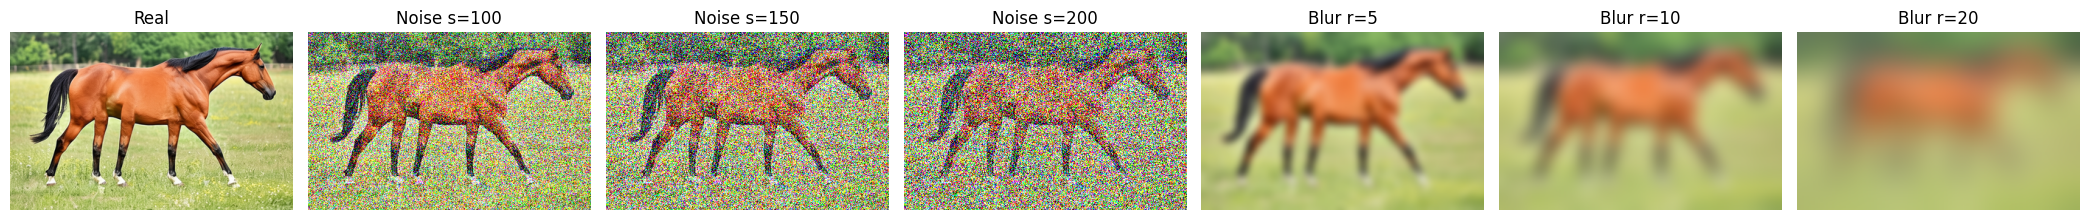

In [24]:
test_img = animal_samples[0]["image"].convert("RGB")

variants = [
    ("Real", test_img),
    ("Noise s=100", distort_image(test_img, "noise", 100, seed=0)),
    ("Noise s=150", distort_image(test_img, "noise", 150, seed=0)),
    ("Noise s=200", distort_image(test_img, "noise", 200, seed=0)),
    ("Blur r=5", distort_image(test_img, "blur", 5)),
    ("Blur r=10", distort_image(test_img, "blur", 10)),
    ("Blur r=20", distort_image(test_img, "blur", 20)),
]

fig, axes = plt.subplots(1, len(variants), figsize=(3 * len(variants), 4))
for ax, (name, img) in zip(axes, variants):
    ax.imshow(img)
    ax.set_title(name)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [25]:
def analyze_sample_vcd_v2(sample, method, strength, seed=0):
    """VCD analysis with configurable distortion method."""
    gt = str(sample["ground_truth"])
    bias = str(sample["expected_bias"])
    real_img = sample["image"].convert("RGB")
    distorted_img = distort_image(real_img, method, strength, seed=seed)

    gold = score_sequence_vcd(real_img, distorted_img, sample["prompt"], gt)
    biased = score_sequence_vcd(real_img, distorted_img, sample["prompt"], bias)

    return {
        "topic": sample["topic"],
        "question_type": sample["type_of_question"],
        "ground_truth": gt,
        "expected_bias": bias,
        "method": method,
        "strength": strength,
        "gold_real_avg_logprob": gold["real_avg_logprob"],
        "gold_noisy_avg_logprob": gold["noisy_avg_logprob"],
        "bias_real_avg_logprob": biased["real_avg_logprob"],
        "bias_noisy_avg_logprob": biased["noisy_avg_logprob"],
        "gold_real_entropy_step1": gold["real_entropy_step1"],
        "gold_noisy_entropy_step1": gold["noisy_entropy_step1"],
        "gold_n_tokens": gold["n_tokens"],
        "bias_n_tokens": biased["n_tokens"],
    }

In [26]:
configs = [
    ("blur", 5),
    ("blur", 10),
    ("blur", 20),
    ("noise", 150),  # keep noise=150 as comparison anchor
]

records = []
for method, strength in configs:
    for sample in tqdm(animal_samples[:20], desc=f"Animals {method}={strength}"):
        records.append({**analyze_sample_vcd_v2(sample, method, strength), "domain": "Animals"})
    for sample in tqdm(patterned_samples[:20], desc=f"PG {method}={strength}"):
        records.append({**analyze_sample_vcd_v2(sample, method, strength), "domain": "Patterned Grid"})

distort_df = pd.DataFrame(records)

distort_df["real_margin"] = distort_df["gold_real_avg_logprob"] - distort_df["bias_real_avg_logprob"]
distort_df["noisy_margin"] = distort_df["gold_noisy_avg_logprob"] - distort_df["bias_noisy_avg_logprob"]
distort_df["margin_shift"] = distort_df["noisy_margin"] - distort_df["real_margin"]

# Bias logprob shift: positive means bias became MORE likely with distortion
distort_df["bias_lp_shift"] = distort_df["bias_noisy_avg_logprob"] - distort_df["bias_real_avg_logprob"]
distort_df["gold_lp_shift"] = distort_df["gold_noisy_avg_logprob"] - distort_df["gold_real_avg_logprob"]

print("=== Mean shifts per domain x distortion ===")
print("VCD wants: bias_lp_shift > 0 (priors activated), margin_shift < 0 (more biased w/o vision)\n")
agg = distort_df.groupby(["domain", "method", "strength"]).agg(
    real_margin=("real_margin", "mean"),
    noisy_margin=("noisy_margin", "mean"),
    margin_shift=("margin_shift", "mean"),
    gold_lp_shift=("gold_lp_shift", "mean"),
    bias_lp_shift=("bias_lp_shift", "mean"),
).round(3)
print(agg)

PG noise=150: 100%|████████████████████████████████████████████████████████████| 20/20 [00:47<00:00,  2.40s/it]

=== Mean shifts per domain x distortion ===
VCD wants: bias_lp_shift > 0 (priors activated), margin_shift < 0 (more biased w/o vision)

                                real_margin  noisy_margin  margin_shift  \
domain         method strength                                            
Animals        blur   5              -9.932        -9.655         0.277   
                      10             -9.932        -9.459         0.472   
                      20             -9.932        -7.588         2.343   
               noise  150            -9.932        -9.020         0.912   
Patterned Grid blur   5              -2.163        -1.349         0.814   
                      10             -2.163        -0.388         1.776   
                      20             -2.163        -0.187         1.977   
               noise  150            -2.163        -1.141         1.022   

                                gold_lp_shift  bias_lp_shift  
domain         method strength                    

In [27]:
TOPICS = ["Animals", "Chess Pieces", "Flags", "Game Boards", "Logos", "Patterned Grid"]
PILOT_N = 20

# Build per-topic sample lists
samples_by_topic = {t: [s for s in ds if s.get("topic") == t][:PILOT_N] for t in TOPICS}
for t, samples in samples_by_topic.items():
    print(f"{t}: {len(samples)} samples")

records = []
for topic in TOPICS:
    for sample in tqdm(samples_by_topic[topic], desc=topic):
        try:
            r = analyze_sample_vcd_v2(sample, method="blur", strength=10, seed=0)
            r["domain"] = topic
            records.append(r)
        except Exception as e:
            print(f"Failed on {topic}: {e}")

cross_df = pd.DataFrame(records)

# Margins
cross_df["real_margin"] = cross_df["gold_real_avg_logprob"] - cross_df["bias_real_avg_logprob"]
cross_df["noisy_margin"] = cross_df["gold_noisy_avg_logprob"] - cross_df["bias_noisy_avg_logprob"]
cross_df["margin_shift"] = cross_df["noisy_margin"] - cross_df["real_margin"]
cross_df["gold_lp_shift"] = cross_df["gold_noisy_avg_logprob"] - cross_df["gold_real_avg_logprob"]
cross_df["bias_lp_shift"] = cross_df["bias_noisy_avg_logprob"] - cross_df["bias_real_avg_logprob"]

# Alpha sweep, post-hoc
for alpha in [0.5, 1.0, 2.0]:
    gold_c = (1 + alpha) * cross_df["gold_real_avg_logprob"] - alpha * cross_df["gold_noisy_avg_logprob"]
    bias_c = (1 + alpha) * cross_df["bias_real_avg_logprob"] - alpha * cross_df["bias_noisy_avg_logprob"]
    cross_df[f"vcd_margin_a{alpha}"] = gold_c - bias_c

print("\n=== Cross-domain summary (blur r=10, Qwen-7B) ===")
print("Diagnostic: VCD assumes bias_lp_shift > 0. If consistently negative, VCD's premise fails.\n")
agg = cross_df.groupby("domain").agg(
    real_margin=("real_margin", "mean"),
    margin_shift=("margin_shift", "mean"),
    gold_lp_shift=("gold_lp_shift", "mean"),
    bias_lp_shift=("bias_lp_shift", "mean"),
).round(3)
print(agg)

print("\n=== % prefers gold per alpha ===")
prefers = cross_df.groupby("domain").agg(
    real=("real_margin", lambda x: (x > 0).mean() * 100),
    vcd_a05=("vcd_margin_a0.5", lambda x: (x > 0).mean() * 100),
    vcd_a1=("vcd_margin_a1.0", lambda x: (x > 0).mean() * 100),
    vcd_a2=("vcd_margin_a2.0", lambda x: (x > 0).mean() * 100),
).round(1)
print(prefers)

Animals: 20 samples
Chess Pieces: 20 samples
Flags: 20 samples
Game Boards: 20 samples
Logos: 20 samples
Patterned Grid: 20 samples


Patterned Grid: 100%|██████████████████████████████████████████████████████████| 20/20 [00:46<00:00,  2.33s/it]


=== Cross-domain summary (blur r=10, Qwen-7B) ===
Diagnostic: VCD assumes bias_lp_shift > 0. If consistently negative, VCD's premise fails.

                real_margin  margin_shift  gold_lp_shift  bias_lp_shift
domain                                                                 
Animals              -9.932         0.472         -0.513         -0.986
Chess Pieces         -4.595         0.905         -0.087         -0.993
Flags                -0.675         0.234         -0.083         -0.316
Game Boards           1.827         2.648          0.317         -2.331
Logos                 0.773        -1.116         -1.686         -0.570
Patterned Grid       -2.163         1.776          1.129         -0.647

=== % prefers gold per alpha ===
                 real  vcd_a05  vcd_a1  vcd_a2
domain                                        
Animals           0.0      0.0     0.0     0.0
Chess Pieces      0.0      0.0     0.0     0.0
Flags            55.0     40.0    40.0    35.0
Game Boards  

In [28]:
cross_df["model"] = "Qwen2.5-VL-7B"
cross_df.to_parquet("vcd_pilot_qwen7b_blur10.parquet")
print(f"Saved {len(cross_df)} rows for Qwen-7B")

Saved 120 rows for Qwen-7B


### Step 9: Cross-model pilot

Run the same blur r=10 distortion sweep on Qwen-3B and LLaVA-7B. Confirm whether the cross-domain pattern from Qwen-7B (universal negative bias_lp_shift, Logos as accidental winner) is architecture-general or Qwen-7B-specific.

Workflow per model:
1. Free current model from GPU memory
2. Load new model + processor (overwrite globals)
3. Run pilot
4. Save dataframe with model name

In [29]:
import gc

def free_model():
    global model, processor
    try:
        del model
        del processor
    except NameError:
        pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print("GPU memory freed")

In [30]:
free_model()

MODEL_ID = "Qwen/Qwen2.5-VL-3B-Instruct"
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
)
model.eval()
print(f"Loaded {MODEL_ID}")

GPU memory freed


preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

Loaded Qwen/Qwen2.5-VL-3B-Instruct


In [31]:
records = []
for topic in TOPICS:
    for sample in tqdm(samples_by_topic[topic], desc=f"Qwen-3B {topic}"):
        try:
            r = analyze_sample_vcd_v2(sample, method="blur", strength=10, seed=0)
            r["domain"] = topic
            r["model"] = "Qwen2.5-VL-3B"
            records.append(r)
        except Exception as e:
            print(f"Failed on {topic}: {e}")

qwen3b_df = pd.DataFrame(records)
qwen3b_df["real_margin"] = qwen3b_df["gold_real_avg_logprob"] - qwen3b_df["bias_real_avg_logprob"]
qwen3b_df["noisy_margin"] = qwen3b_df["gold_noisy_avg_logprob"] - qwen3b_df["bias_noisy_avg_logprob"]
qwen3b_df["margin_shift"] = qwen3b_df["noisy_margin"] - qwen3b_df["real_margin"]
qwen3b_df["gold_lp_shift"] = qwen3b_df["gold_noisy_avg_logprob"] - qwen3b_df["gold_real_avg_logprob"]
qwen3b_df["bias_lp_shift"] = qwen3b_df["bias_noisy_avg_logprob"] - qwen3b_df["bias_real_avg_logprob"]

for alpha in [0.5, 1.0, 2.0]:
    gold_c = (1 + alpha) * qwen3b_df["gold_real_avg_logprob"] - alpha * qwen3b_df["gold_noisy_avg_logprob"]
    bias_c = (1 + alpha) * qwen3b_df["bias_real_avg_logprob"] - alpha * qwen3b_df["bias_noisy_avg_logprob"]
    qwen3b_df[f"vcd_margin_a{alpha}"] = gold_c - bias_c

qwen3b_df.to_parquet("vcd_pilot_qwen3b_blur10.parquet")

print("\n=== Qwen-3B summary (blur r=10) ===")
print(qwen3b_df.groupby("domain").agg(
    real_margin=("real_margin", "mean"),
    margin_shift=("margin_shift", "mean"),
    gold_lp_shift=("gold_lp_shift", "mean"),
    bias_lp_shift=("bias_lp_shift", "mean"),
).round(3))

print("\n=== Qwen-3B % prefers gold per alpha ===")
print(qwen3b_df.groupby("domain").agg(
    real=("real_margin", lambda x: (x > 0).mean() * 100),
    vcd_a05=("vcd_margin_a0.5", lambda x: (x > 0).mean() * 100),
    vcd_a1=("vcd_margin_a1.0", lambda x: (x > 0).mean() * 100),
    vcd_a2=("vcd_margin_a2.0", lambda x: (x > 0).mean() * 100),
).round(1))

Qwen-3B Patterned Grid: 100%|██████████████████████████████████████████████████| 20/20 [00:34<00:00,  1.72s/it]


=== Qwen-3B summary (blur r=10) ===
                real_margin  margin_shift  gold_lp_shift  bias_lp_shift
domain                                                                 
Animals              -3.802        -0.783         -0.639          0.145
Chess Pieces         -2.066         0.705         -1.408         -2.113
Flags                -0.923         0.289         -1.436         -1.725
Game Boards           6.135         0.556         -0.308         -0.864
Logos                -0.836        -0.136         -0.571         -0.435
Patterned Grid        0.264         0.617         -0.519         -1.136

=== Qwen-3B % prefers gold per alpha ===
                 real  vcd_a05  vcd_a1  vcd_a2
domain                                        
Animals           0.0      0.0     0.0    10.0
Chess Pieces      0.0      0.0     0.0     0.0
Flags            50.0     50.0    50.0    50.0
Game Boards     100.0    100.0   100.0   100.0
Logos             0.0      0.0     0.0    10.0
Patterned Grid  

In [32]:
free_model()

GPU memory freed


In [33]:
from transformers import LlavaOnevisionForConditionalGeneration, AutoProcessor

MODEL_ID = "llava-hf/llava-onevision-qwen2-7b-ov-hf"

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = LlavaOnevisionForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
)
model.eval()
print(f"Loaded {MODEL_ID}")

processor_config.json:   0%|          | 0.00/178 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/826 [00:00<?, ?B/s]

preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/765 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/126 [00:00<?, ?B/s]

Loaded llava-hf/llava-onevision-qwen2-7b-ov-hf


In [35]:
records = []
for topic in TOPICS:
    for sample in tqdm(samples_by_topic[topic], desc=f"LLaVA {topic}"):
        try:
            r = analyze_sample_vcd_v2(sample, method="blur", strength=10, seed=0)
            r["domain"] = topic
            r["model"] = "LLaVA-OneVision-7B"
            records.append(r)
        except Exception as e:
            print(f"Failed on {topic}: {e}")

llava_df = pd.DataFrame(records)
llava_df["real_margin"] = llava_df["gold_real_avg_logprob"] - llava_df["bias_real_avg_logprob"]
llava_df["noisy_margin"] = llava_df["gold_noisy_avg_logprob"] - llava_df["bias_noisy_avg_logprob"]
llava_df["margin_shift"] = llava_df["noisy_margin"] - llava_df["real_margin"]
llava_df["gold_lp_shift"] = llava_df["gold_noisy_avg_logprob"] - llava_df["gold_real_avg_logprob"]
llava_df["bias_lp_shift"] = llava_df["bias_noisy_avg_logprob"] - llava_df["bias_real_avg_logprob"]

for alpha in [0.5, 1.0, 2.0]:
    gold_c = (1 + alpha) * llava_df["gold_real_avg_logprob"] - alpha * llava_df["gold_noisy_avg_logprob"]
    bias_c = (1 + alpha) * llava_df["bias_real_avg_logprob"] - alpha * llava_df["bias_noisy_avg_logprob"]
    llava_df[f"vcd_margin_a{alpha}"] = gold_c - bias_c

llava_df.to_parquet("vcd_pilot_llava7b_blur10.parquet")

print("\n=== LLaVA-OneVision-7B summary (blur r=10) ===")
print(llava_df.groupby("domain").agg(
    real_margin=("real_margin", "mean"),
    margin_shift=("margin_shift", "mean"),
    gold_lp_shift=("gold_lp_shift", "mean"),
    bias_lp_shift=("bias_lp_shift", "mean"),
).round(3))

print("\n=== LLaVA-OneVision-7B % prefers gold per alpha ===")
print(llava_df.groupby("domain").agg(
    real=("real_margin", lambda x: (x > 0).mean() * 100),
    vcd_a05=("vcd_margin_a0.5", lambda x: (x > 0).mean() * 100),
    vcd_a1=("vcd_margin_a1.0", lambda x: (x > 0).mean() * 100),
    vcd_a2=("vcd_margin_a2.0", lambda x: (x > 0).mean() * 100),
).round(1))


LLaVA Animals: 100%|███████████████████████████████████████████████████████████| 20/20 [01:31<00:00,  4.57s/it]

LLaVA Patterned Grid: 100%|████████████████████████████████████████████████████| 20/20 [01:57<00:00,  5.85s/it]


=== LLaVA-OneVision-7B summary (blur r=10) ===
                real_margin  margin_shift  gold_lp_shift  bias_lp_shift
domain                                                                 
Animals              -7.938         1.081          0.620         -0.461
Chess Pieces         -1.453         0.511          0.248         -0.264
Flags                 0.399        -0.547         -0.450          0.098
Game Boards          -0.683         0.552          1.289          0.737
Logos                 1.128        -0.804         -0.964         -0.160
Patterned Grid       -0.974         0.255         -0.703         -0.958

=== LLaVA-OneVision-7B % prefers gold per alpha ===
                real  vcd_a05  vcd_a1  vcd_a2
domain                                       
Animals          0.0      0.0     0.0     0.0
Chess Pieces     5.0      5.0     5.0     5.0
Flags           70.0     60.0    60.0    60.0
Game Boards     50.0     50.0    50.0    45.0
Logos           85.0     85.0    85.0    85.0
P

### Step 10: Combine pilot results across models

Load the three parquets, stack into one master dataframe. All subsequent cross-model analysis pulls from this.

In [36]:
qwen7b = pd.read_parquet("vcd_pilot_qwen7b_blur10.parquet")
qwen3b = pd.read_parquet("vcd_pilot_qwen3b_blur10.parquet")
llava = pd.read_parquet("vcd_pilot_llava7b_blur10.parquet")

master = pd.concat([qwen7b, qwen3b, llava], ignore_index=True)

print(f"Total rows: {len(master)}")
print(f"Models: {master['model'].unique().tolist()}")
print(f"Domains: {master['domain'].unique().tolist()}")
print(f"Rows per model x domain:")
print(master.groupby(["model", "domain"]).size().unstack())

Total rows: 360
Models: ['Qwen2.5-VL-7B', 'Qwen2.5-VL-3B', 'LLaVA-OneVision-7B']
Domains: ['Animals', 'Chess Pieces', 'Flags', 'Game Boards', 'Logos', 'Patterned Grid']
Rows per model x domain:
domain              Animals  Chess Pieces  Flags  Game Boards  Logos  \
model                                                                  
LLaVA-OneVision-7B       20            20     20           20     20   
Qwen2.5-VL-3B            20            20     20           20     20   
Qwen2.5-VL-7B            20            20     20           20     20   

domain              Patterned Grid  
model                               
LLaVA-OneVision-7B              20  
Qwen2.5-VL-3B                   20  
Qwen2.5-VL-7B                   20  


### bias_lp_shift heatmap

Visualizes the core finding: across 3 models and 6 domains, does distortion activate language priors (positive, VCD-friendly) or not (negative, VCD's assumption fails)?

Red = positive (VCD's assumption holds), blue = negative (assumption fails). Diverging colormap centered at zero.

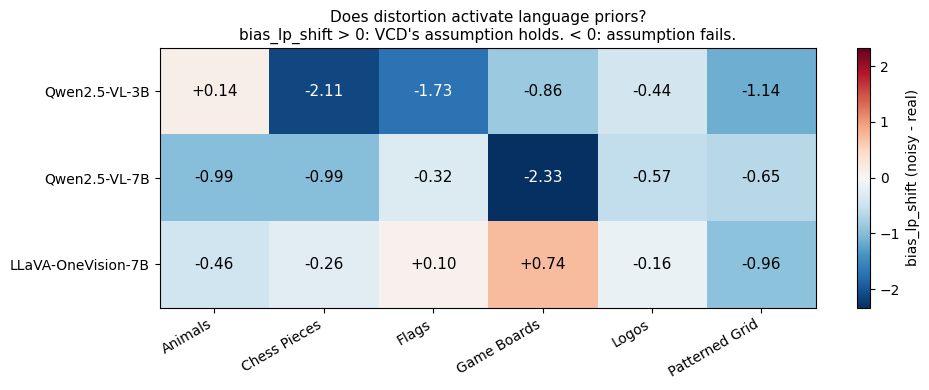


15 of 18 cells negative (15/18)
Mean across all cells: -0.721


In [37]:
# Pivot to model x domain matrix
heatmap_data = master.groupby(["model", "domain"])["bias_lp_shift"].mean().unstack()

# Reorder for readability
model_order = ["Qwen2.5-VL-3B", "Qwen2.5-VL-7B", "LLaVA-OneVision-7B"]
domain_order = ["Animals", "Chess Pieces", "Flags", "Game Boards", "Logos", "Patterned Grid"]
heatmap_data = heatmap_data.reindex(index=model_order, columns=domain_order)

fig, ax = plt.subplots(figsize=(10, 4))
vmax = max(abs(heatmap_data.min().min()), abs(heatmap_data.max().max()))

im = ax.imshow(heatmap_data.values, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")

# Annotations
for i in range(len(model_order)):
    for j in range(len(domain_order)):
        val = heatmap_data.values[i, j]
        color = "white" if abs(val) > vmax * 0.5 else "black"
        ax.text(j, i, f"{val:+.2f}", ha="center", va="center", color=color, fontsize=11)

ax.set_xticks(range(len(domain_order)))
ax.set_xticklabels(domain_order, rotation=30, ha="right")
ax.set_yticks(range(len(model_order)))
ax.set_yticklabels(model_order)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("bias_lp_shift (noisy - real)")

ax.set_title("Does distortion activate language priors?\nbias_lp_shift > 0: VCD's assumption holds. < 0: assumption fails.",
             fontsize=11)

plt.tight_layout()
plt.savefig("bias_lp_shift_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n15 of 18 cells negative ({(heatmap_data.values < 0).sum()}/18)")
print(f"Mean across all cells: {heatmap_data.values.mean():+.3f}")

### Effect of VCD on % prefers gold

For each model x domain, compare the percentage of samples where the gold candidate beats the bias candidate, before VCD (real margin) and after VCD at alpha=1.0. If VCD works, the after-bar should be higher than the before-bar.

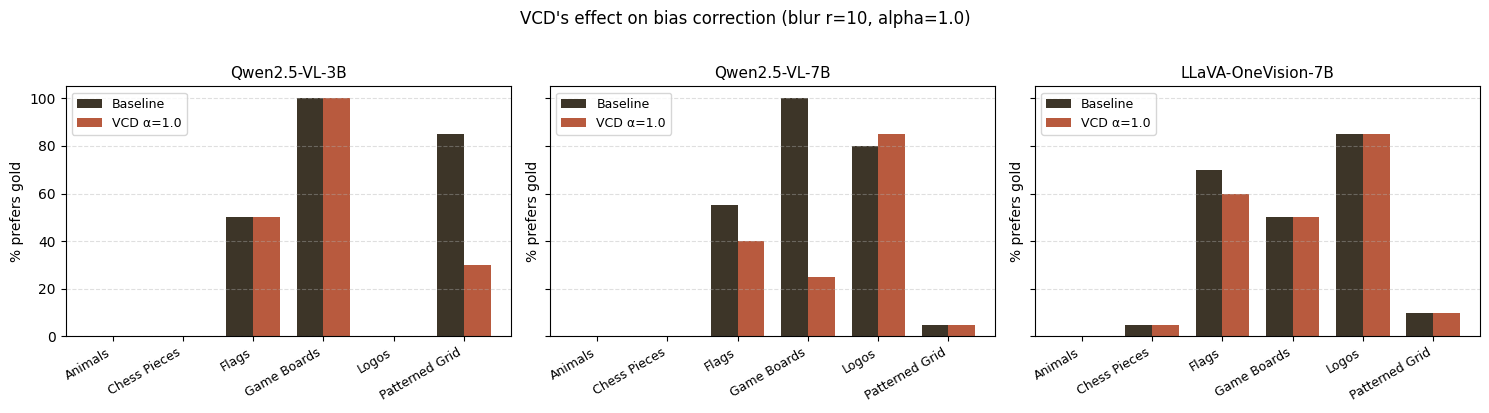


=== Delta in % prefers gold (VCD - baseline), per model x domain ===
domain              Animals  Chess Pieces  Flags  Game Boards  Logos  \
model                                                                  
Qwen2.5-VL-3B           0.0           0.0    0.0          0.0    0.0   
Qwen2.5-VL-7B           0.0           0.0  -15.0        -75.0    5.0   
LLaVA-OneVision-7B      0.0           0.0  -10.0          0.0    0.0   

domain              Patterned Grid  
model                               
Qwen2.5-VL-3B                -55.0  
Qwen2.5-VL-7B                  0.0  
LLaVA-OneVision-7B             0.0  


In [38]:
# Compute % prefers gold for each model x domain
def pct_prefers_gold(col):
    return (col > 0).mean() * 100

agg = master.groupby(["model", "domain"]).agg(
    pct_real=("real_margin", pct_prefers_gold),
    pct_vcd_a1=("vcd_margin_a1.0", pct_prefers_gold),
).reset_index()

agg["delta"] = agg["pct_vcd_a1"] - agg["pct_real"]

# Plot grouped bars
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, mdl in zip(axes, model_order):
    sub = agg[agg["model"] == mdl].set_index("domain").reindex(domain_order).reset_index()
    x = np.arange(len(sub))
    width = 0.38
    ax.bar(x - width/2, sub["pct_real"], width, label="Baseline", color="#3D3528")
    ax.bar(x + width/2, sub["pct_vcd_a1"], width, label="VCD α=1.0", color="#B85A3E")
    ax.set_xticks(x)
    ax.set_xticklabels(sub["domain"], rotation=30, ha="right", fontsize=9)
    ax.set_ylim(0, 105)
    ax.set_title(mdl, fontsize=11)
    ax.set_ylabel("% prefers gold")
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("VCD's effect on bias correction (blur r=10, alpha=1.0)", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig("vcd_pct_prefers_gold.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== Delta in % prefers gold (VCD - baseline), per model x domain ===")
print(agg.pivot(index="model", columns="domain", values="delta").reindex(model_order)[domain_order].round(1))

### Mean margin shift from VCD (alpha=1.0)

For each model x domain, the average gain in margin from applying VCD. Positive means VCD pushed gold logprobs up relative to bias. Negative means VCD made things worse.

This shows magnitude, not just whether samples flipped past zero.

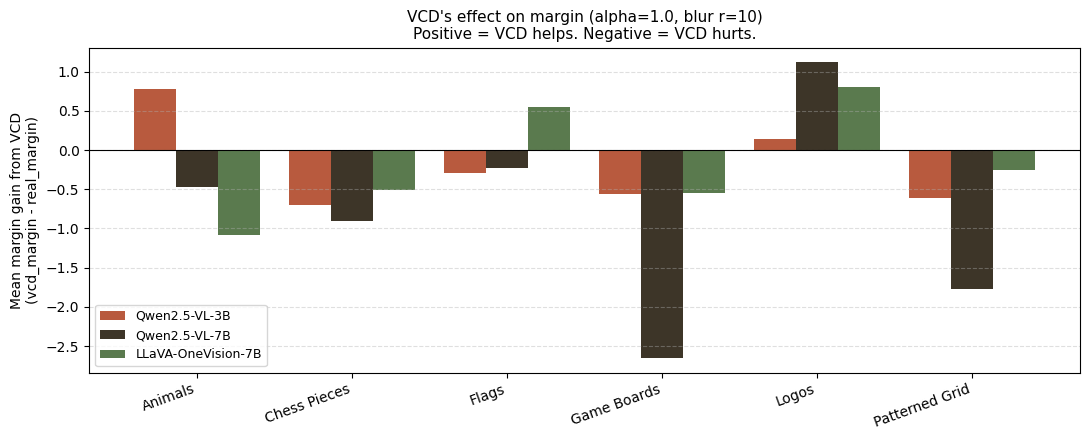


=== Mean margin gain from VCD per cell ===
domain              Animals  Chess Pieces  Flags  Game Boards  Logos  \
model                                                                  
Qwen2.5-VL-3B         0.783        -0.705 -0.289       -0.556  0.136   
Qwen2.5-VL-7B        -0.472        -0.905 -0.234       -2.648  1.116   
LLaVA-OneVision-7B   -1.081        -0.511  0.547       -0.552  0.804   

domain              Patterned Grid  
model                               
Qwen2.5-VL-3B               -0.617  
Qwen2.5-VL-7B               -1.776  
LLaVA-OneVision-7B          -0.255  


In [39]:
master["vcd_gain_a1"] = master["vcd_margin_a1.0"] - master["real_margin"]

gain = master.groupby(["model", "domain"])["vcd_gain_a1"].mean().unstack()
gain = gain.reindex(index=model_order, columns=domain_order)

fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(domain_order))
width = 0.27

colors = {"Qwen2.5-VL-3B": "#B85A3E", "Qwen2.5-VL-7B": "#3D3528", "LLaVA-OneVision-7B": "#5A7A4E"}

for i, mdl in enumerate(model_order):
    offset = (i - 1) * width
    ax.bar(x + offset, gain.loc[mdl].values, width, label=mdl, color=colors[mdl])

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(domain_order, rotation=20, ha="right")
ax.set_ylabel("Mean margin gain from VCD\n(vcd_margin - real_margin)")
ax.set_title("VCD's effect on margin (alpha=1.0, blur r=10)\nPositive = VCD helps. Negative = VCD hurts.", fontsize=11)
ax.legend(loc="lower left", fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("vcd_margin_gain.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== Mean margin gain from VCD per cell ===")
print(gain.round(3))

### Per-sample VCD effect: real margin vs VCD margin

For each sample, plot real_margin (x) vs vcd_margin at alpha=1.0 (y). Points on the y=x line are unchanged. Above the line: VCD helped. Below the line: VCD hurt. Color by model, facet by domain.

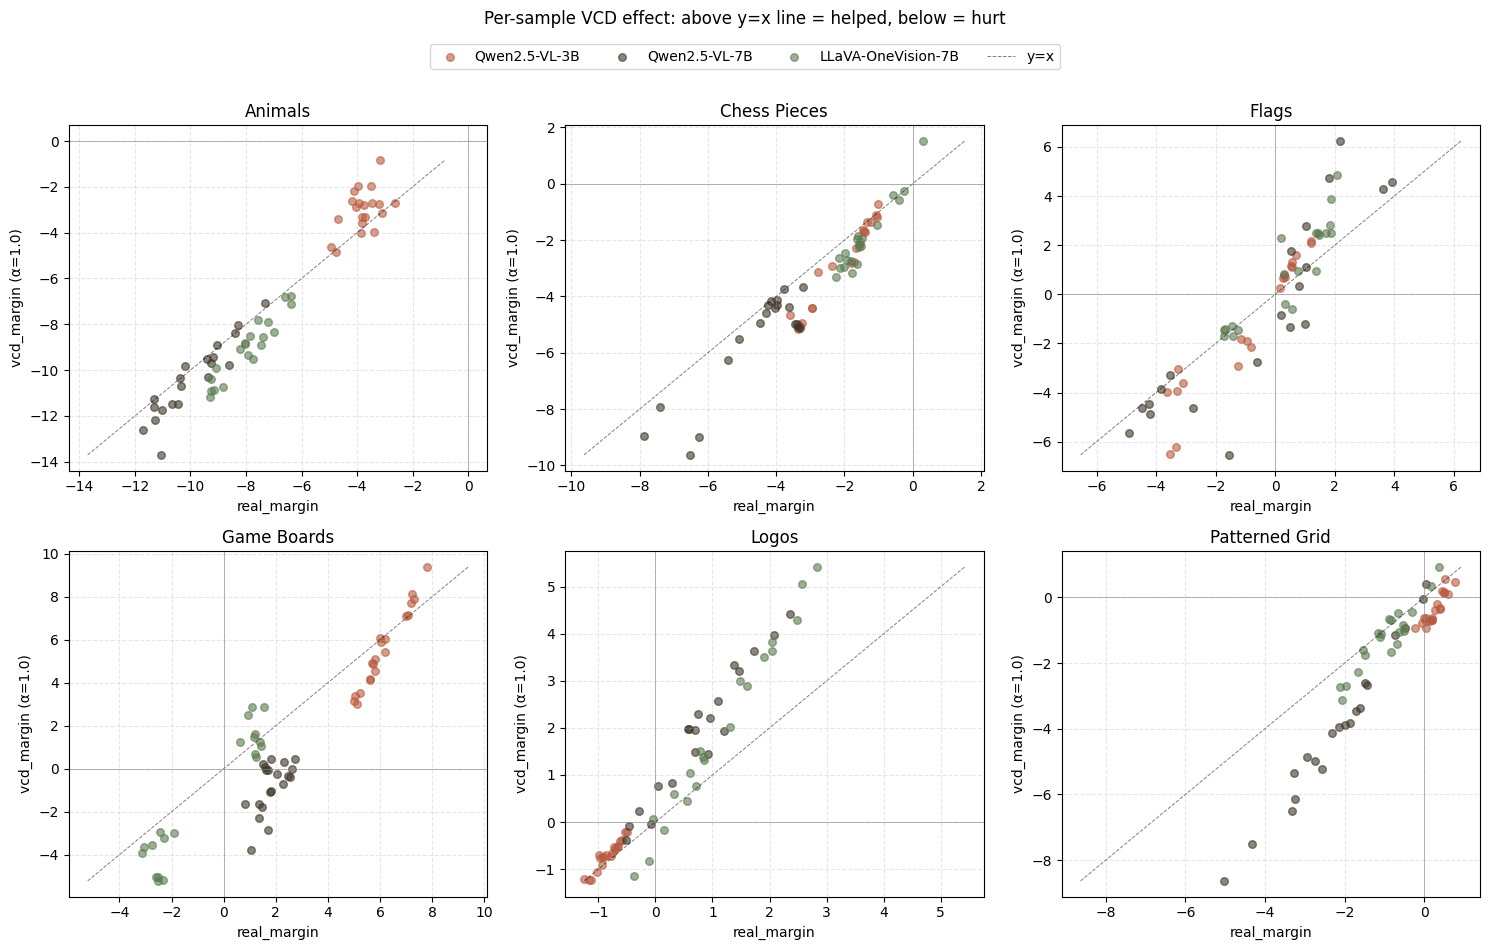


=== % of samples where VCD helped (vcd_margin > real_margin) ===
domain              Animals  Chess Pieces  Flags  Game Boards  Logos  \
model                                                                  
Qwen2.5-VL-3B          75.0           5.0   55.0         35.0   85.0   
Qwen2.5-VL-7B          35.0          10.0   45.0          0.0  100.0   
LLaVA-OneVision-7B      0.0          10.0   75.0         30.0   80.0   

domain              Patterned Grid  
model                               
Qwen2.5-VL-3B                  5.0  
Qwen2.5-VL-7B                  5.0  
LLaVA-OneVision-7B            30.0  


In [40]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=False, sharey=False)
axes = axes.flatten()

for ax, domain in zip(axes, domain_order):
    sub = master[master["domain"] == domain]
    for mdl in model_order:
        m_sub = sub[sub["model"] == mdl]
        ax.scatter(m_sub["real_margin"], m_sub["vcd_margin_a1.0"],
                   alpha=0.6, s=30, color=colors[mdl], label=mdl)

    # y=x reference
    all_vals = pd.concat([sub["real_margin"], sub["vcd_margin_a1.0"]])
    mn, mx = all_vals.min(), all_vals.max()
    ax.plot([mn, mx], [mn, mx], "k--", linewidth=0.7, alpha=0.5, label="y=x")
    ax.axhline(0, color="gray", linewidth=0.4)
    ax.axvline(0, color="gray", linewidth=0.4)

    ax.set_xlabel("real_margin")
    ax.set_ylabel("vcd_margin (α=1.0)")
    ax.set_title(domain)
    ax.grid(linestyle="--", alpha=0.3)

# Single legend for the whole figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.02), fontsize=10)

plt.suptitle("Per-sample VCD effect: above y=x line = helped, below = hurt", y=1.05, fontsize=12)
plt.tight_layout()
plt.savefig("vcd_per_sample_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

# Quantify: % of samples helped (above y=x), per model x domain
master["helped_a1"] = master["vcd_margin_a1.0"] > master["real_margin"]
helped_pct = master.groupby(["model", "domain"])["helped_a1"].apply(lambda x: x.mean() * 100).unstack()
helped_pct = helped_pct.reindex(index=model_order, columns=domain_order)

print("\n=== % of samples where VCD helped (vcd_margin > real_margin) ===")
print(helped_pct.round(1))

In [41]:
master.to_parquet("vcd_pilot_master_3models_blur10.parquet")
print("Saved master dataframe")

Saved master dataframe


### Step 11: Cross-model pilot with noise distortion

Same setup as the blur pilot (20 samples × 6 domains × 3 models, alpha sweep), but with Gaussian noise sigma=100 instead of blur r=10. This tests whether the cross-model finding (universal negative bias_lp_shift, VCD's assumption fails) is distortion-method-specific or holds across distortions.

Workflow: per model, free memory, load, run noise pilot, save parquet. Then combine.

In [42]:
free_model()

MODEL_ID = "Qwen/Qwen2.5-VL-7B-Instruct"
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
)
model.eval()
print(f"Loaded {MODEL_ID}")

GPU memory freed


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Loaded Qwen/Qwen2.5-VL-7B-Instruct


In [43]:
records = []
for topic in TOPICS:
    for sample in tqdm(samples_by_topic[topic], desc=f"Qwen-7B noise {topic}"):
        try:
            r = analyze_sample_vcd_v2(sample, method="noise", strength=100, seed=0)
            r["domain"] = topic
            r["model"] = "Qwen2.5-VL-7B"
            records.append(r)
        except Exception as e:
            print(f"Failed: {e}")

qwen7b_noise_df = pd.DataFrame(records)
qwen7b_noise_df["real_margin"] = qwen7b_noise_df["gold_real_avg_logprob"] - qwen7b_noise_df["bias_real_avg_logprob"]
qwen7b_noise_df["noisy_margin"] = qwen7b_noise_df["gold_noisy_avg_logprob"] - qwen7b_noise_df["bias_noisy_avg_logprob"]
qwen7b_noise_df["margin_shift"] = qwen7b_noise_df["noisy_margin"] - qwen7b_noise_df["real_margin"]
qwen7b_noise_df["gold_lp_shift"] = qwen7b_noise_df["gold_noisy_avg_logprob"] - qwen7b_noise_df["gold_real_avg_logprob"]
qwen7b_noise_df["bias_lp_shift"] = qwen7b_noise_df["bias_noisy_avg_logprob"] - qwen7b_noise_df["bias_real_avg_logprob"]

for alpha in [0.5, 1.0, 2.0]:
    gold_c = (1 + alpha) * qwen7b_noise_df["gold_real_avg_logprob"] - alpha * qwen7b_noise_df["gold_noisy_avg_logprob"]
    bias_c = (1 + alpha) * qwen7b_noise_df["bias_real_avg_logprob"] - alpha * qwen7b_noise_df["bias_noisy_avg_logprob"]
    qwen7b_noise_df[f"vcd_margin_a{alpha}"] = gold_c - bias_c

qwen7b_noise_df.to_parquet("vcd_pilot_qwen7b_noise100.parquet")
print(f"Saved Qwen-7B noise pilot ({len(qwen7b_noise_df)} rows)")

Qwen-7B noise Patterned Grid: 100%|████████████████████████████████████████████| 20/20 [00:46<00:00,  2.33s/it]

Saved Qwen-7B noise pilot (120 rows)


In [44]:
free_model()

MODEL_ID = "Qwen/Qwen2.5-VL-3B-Instruct"
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
)
model.eval()
print(f"Loaded {MODEL_ID}")

GPU memory freed


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Loaded Qwen/Qwen2.5-VL-3B-Instruct


In [45]:
records = []
for topic in TOPICS:
    for sample in tqdm(samples_by_topic[topic], desc=f"Qwen-3B noise {topic}"):
        try:
            r = analyze_sample_vcd_v2(sample, method="noise", strength=100, seed=0)
            r["domain"] = topic
            r["model"] = "Qwen2.5-VL-3B"
            records.append(r)
        except Exception as e:
            print(f"Failed: {e}")

qwen3b_noise_df = pd.DataFrame(records)
qwen3b_noise_df["real_margin"] = qwen3b_noise_df["gold_real_avg_logprob"] - qwen3b_noise_df["bias_real_avg_logprob"]
qwen3b_noise_df["noisy_margin"] = qwen3b_noise_df["gold_noisy_avg_logprob"] - qwen3b_noise_df["bias_noisy_avg_logprob"]
qwen3b_noise_df["margin_shift"] = qwen3b_noise_df["noisy_margin"] - qwen3b_noise_df["real_margin"]
qwen3b_noise_df["gold_lp_shift"] = qwen3b_noise_df["gold_noisy_avg_logprob"] - qwen3b_noise_df["gold_real_avg_logprob"]
qwen3b_noise_df["bias_lp_shift"] = qwen3b_noise_df["bias_noisy_avg_logprob"] - qwen3b_noise_df["bias_real_avg_logprob"]

for alpha in [0.5, 1.0, 2.0]:
    gold_c = (1 + alpha) * qwen3b_noise_df["gold_real_avg_logprob"] - alpha * qwen3b_noise_df["gold_noisy_avg_logprob"]
    bias_c = (1 + alpha) * qwen3b_noise_df["bias_real_avg_logprob"] - alpha * qwen3b_noise_df["bias_noisy_avg_logprob"]
    qwen3b_noise_df[f"vcd_margin_a{alpha}"] = gold_c - bias_c

qwen3b_noise_df.to_parquet("vcd_pilot_qwen3b_noise100.parquet")
print(f"Saved Qwen-3B noise pilot ({len(qwen3b_noise_df)} rows)")

Qwen-3B noise Patterned Grid: 100%|████████████████████████████████████████████| 20/20 [00:34<00:00,  1.74s/it]

Saved Qwen-3B noise pilot (120 rows)


In [46]:
free_model()

MODEL_ID = "llava-hf/llava-onevision-qwen2-7b-ov-hf"
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = LlavaOnevisionForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
)
model.eval()
print(f"Loaded {MODEL_ID}")

GPU memory freed


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/765 [00:00<?, ?it/s]

Loaded llava-hf/llava-onevision-qwen2-7b-ov-hf


In [47]:
records = []
for topic in TOPICS:
    for sample in tqdm(samples_by_topic[topic], desc=f"LLaVA noise {topic}"):
        try:
            r = analyze_sample_vcd_v2(sample, method="noise", strength=100, seed=0)
            r["domain"] = topic
            r["model"] = "LLaVA-OneVision-7B"
            records.append(r)
        except Exception as e:
            print(f"Failed: {e}")

llava_noise_df = pd.DataFrame(records)
llava_noise_df["real_margin"] = llava_noise_df["gold_real_avg_logprob"] - llava_noise_df["bias_real_avg_logprob"]
llava_noise_df["noisy_margin"] = llava_noise_df["gold_noisy_avg_logprob"] - llava_noise_df["bias_noisy_avg_logprob"]
llava_noise_df["margin_shift"] = llava_noise_df["noisy_margin"] - llava_noise_df["real_margin"]
llava_noise_df["gold_lp_shift"] = llava_noise_df["gold_noisy_avg_logprob"] - llava_noise_df["gold_real_avg_logprob"]
llava_noise_df["bias_lp_shift"] = llava_noise_df["bias_noisy_avg_logprob"] - llava_noise_df["bias_real_avg_logprob"]

for alpha in [0.5, 1.0, 2.0]:
    gold_c = (1 + alpha) * llava_noise_df["gold_real_avg_logprob"] - alpha * llava_noise_df["gold_noisy_avg_logprob"]
    bias_c = (1 + alpha) * llava_noise_df["bias_real_avg_logprob"] - alpha * llava_noise_df["bias_noisy_avg_logprob"]
    llava_noise_df[f"vcd_margin_a{alpha}"] = gold_c - bias_c

llava_noise_df.to_parquet("vcd_pilot_llava7b_noise100.parquet")
print(f"Saved LLaVA noise pilot ({len(llava_noise_df)} rows)")

LLaVA noise Patterned Grid: 100%|██████████████████████████████████████████████| 20/20 [01:57<00:00,  5.87s/it]

Saved LLaVA noise pilot (120 rows)


In [48]:
# Load noise parquets
qwen7b_n = pd.read_parquet("vcd_pilot_qwen7b_noise100.parquet")
qwen3b_n = pd.read_parquet("vcd_pilot_qwen3b_noise100.parquet")
llava_n = pd.read_parquet("vcd_pilot_llava7b_noise100.parquet")

master_noise = pd.concat([qwen7b_n, qwen3b_n, llava_n], ignore_index=True)
master_noise["distortion"] = "noise_s100"
master_noise.to_parquet("vcd_pilot_master_3models_noise100.parquet")

# Tag the existing blur master
master["distortion"] = "blur_r10"

# Combine for direct comparison
all_pilots = pd.concat([master, master_noise], ignore_index=True)
all_pilots["helped_a1"] = all_pilots["vcd_margin_a1.0"] > all_pilots["real_margin"]

print("=== bias_lp_shift: noise vs blur ===")
shift = all_pilots.groupby(["distortion", "model", "domain"])["bias_lp_shift"].mean().unstack()
shift = shift.reindex(columns=domain_order)
print(shift.round(3))

print("\n=== % prefers gold (vcd α=1.0): noise vs blur ===")
prefers = all_pilots.groupby(["distortion", "model", "domain"])["vcd_margin_a1.0"].apply(lambda x: (x > 0).mean() * 100).unstack()
prefers = prefers.reindex(columns=domain_order)
print(prefers.round(1))

print("\n=== % helped (vcd_margin > real_margin): noise vs blur ===")
helped = all_pilots.groupby(["distortion", "model", "domain"])["helped_a1"].apply(lambda x: x.mean() * 100).unstack()
helped = helped.reindex(columns=domain_order)
print(helped.round(1))

=== bias_lp_shift: noise vs blur ===
domain                         Animals  Chess Pieces  Flags  Game Boards  \
distortion model                                                           
blur_r10   LLaVA-OneVision-7B   -0.461        -0.264  0.098        0.737   
           Qwen2.5-VL-3B         0.145        -2.113 -1.725       -0.864   
           Qwen2.5-VL-7B        -0.986        -0.993 -0.316       -2.331   
noise_s100 LLaVA-OneVision-7B    0.218         0.017  1.316       -0.030   
           Qwen2.5-VL-3B         0.197        -0.570  0.026       -0.574   
           Qwen2.5-VL-7B        -1.083        -0.124  0.200       -0.277   

domain                         Logos  Patterned Grid  
distortion model                                      
blur_r10   LLaVA-OneVision-7B -0.160          -0.958  
           Qwen2.5-VL-3B      -0.435          -1.136  
           Qwen2.5-VL-7B      -0.570          -0.647  
noise_s100 LLaVA-OneVision-7B  0.557          -0.627  
           Qwen2.5-VL-3B

### Step 12: Noise vs blur visual comparison

Side-by-side versions of the bias_lp_shift heatmap and % helped table for noise vs blur. Lets us see at a glance whether the cross-model story holds across distortion methods, and where it diverges.

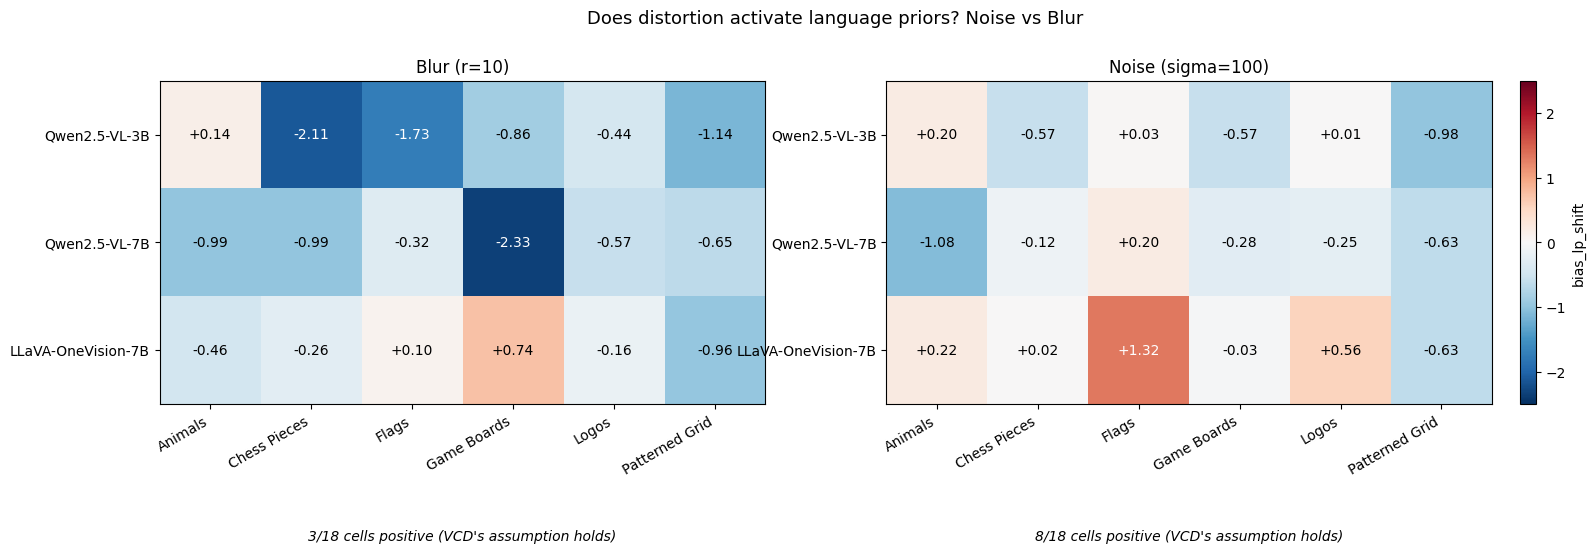

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(18, 4.2))

for ax, distortion, title in zip(
    axes,
    ["blur_r10", "noise_s100"],
    ["Blur (r=10)", "Noise (sigma=100)"],
):
    sub = all_pilots[all_pilots["distortion"] == distortion]
    data = sub.groupby(["model", "domain"])["bias_lp_shift"].mean().unstack()
    data = data.reindex(index=model_order, columns=domain_order)

    vmax = 2.5  # shared scale across both panels
    im = ax.imshow(data.values, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")

    for i in range(len(model_order)):
        for j in range(len(domain_order)):
            val = data.values[i, j]
            color = "white" if abs(val) > vmax * 0.5 else "black"
            ax.text(j, i, f"{val:+.2f}", ha="center", va="center", color=color, fontsize=10)

    ax.set_xticks(range(len(domain_order)))
    ax.set_xticklabels(domain_order, rotation=30, ha="right")
    ax.set_yticks(range(len(model_order)))
    ax.set_yticklabels(model_order)
    ax.set_title(title, fontsize=12)

    n_pos = (data.values > 0).sum()
    ax.text(0.5, -0.42, f"{n_pos}/18 cells positive (VCD's assumption holds)",
            transform=ax.transAxes, ha="center", fontsize=10, style="italic")

fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02, label="bias_lp_shift")
fig.suptitle("Does distortion activate language priors? Noise vs Blur", y=1.05, fontsize=13)

plt.savefig("bias_lp_shift_noise_vs_blur.png", dpi=150, bbox_inches="tight")
plt.show()

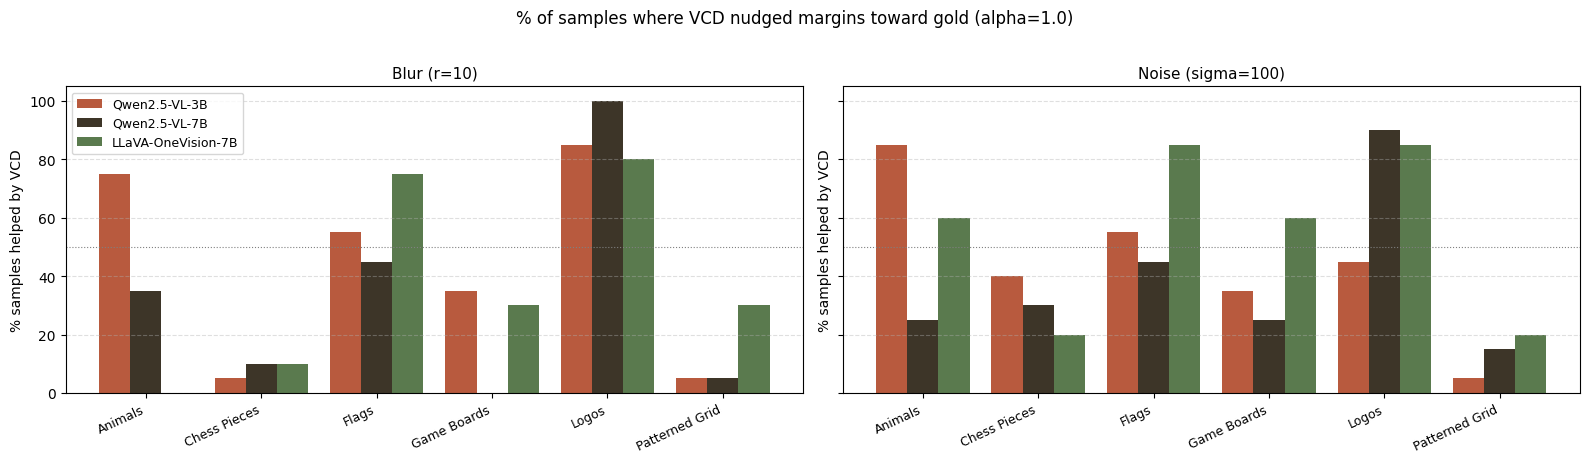


=== Delta in % helped (noise - blur), per model x domain ===
domain              Animals  Chess Pieces  Flags  Game Boards  Logos  \
model                                                                  
Qwen2.5-VL-3B          10.0          35.0    0.0          0.0  -40.0   
Qwen2.5-VL-7B         -10.0          20.0    0.0         25.0  -10.0   
LLaVA-OneVision-7B     60.0          10.0   10.0         30.0    5.0   

domain              Patterned Grid  
model                               
Qwen2.5-VL-3B                  0.0  
Qwen2.5-VL-7B                 10.0  
LLaVA-OneVision-7B           -10.0  


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5), sharey=True)

for ax, distortion, title in zip(
    axes,
    ["blur_r10", "noise_s100"],
    ["Blur (r=10)", "Noise (sigma=100)"],
):
    sub = all_pilots[all_pilots["distortion"] == distortion]
    helped = sub.groupby(["model", "domain"])["helped_a1"].apply(lambda x: x.mean() * 100).unstack()
    helped = helped.reindex(index=model_order, columns=domain_order)

    x = np.arange(len(domain_order))
    width = 0.27
    for i, mdl in enumerate(model_order):
        offset = (i - 1) * width
        ax.bar(x + offset, helped.loc[mdl].values, width, label=mdl, color=colors[mdl])

    ax.axhline(50, color="gray", linewidth=0.8, linestyle=":")
    ax.set_xticks(x)
    ax.set_xticklabels(domain_order, rotation=25, ha="right", fontsize=9)
    ax.set_ylim(0, 105)
    ax.set_ylabel("% samples helped by VCD")
    ax.set_title(title, fontsize=11)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

axes[0].legend(loc="upper left", fontsize=9)
fig.suptitle("% of samples where VCD nudged margins toward gold (alpha=1.0)", y=1.02, fontsize=12)

plt.tight_layout()
plt.savefig("vcd_helped_noise_vs_blur.png", dpi=150, bbox_inches="tight")
plt.show()

# Quick cross-distortion delta
print("\n=== Delta in % helped (noise - blur), per model x domain ===")
helped_blur = all_pilots[all_pilots["distortion"] == "blur_r10"].groupby(["model", "domain"])["helped_a1"].apply(lambda x: x.mean() * 100).unstack()
helped_noise = all_pilots[all_pilots["distortion"] == "noise_s100"].groupby(["model", "domain"])["helped_a1"].apply(lambda x: x.mean() * 100).unstack()
delta = (helped_noise - helped_blur).reindex(index=model_order, columns=domain_order)
print(delta.round(1))

In [51]:
# Save final master combining both distortions
all_pilots.to_parquet("vcd_pilot_master_3models_blur10_AND_noise100.parquet")
print(f"Saved master: {len(all_pilots)} rows")

Saved master: 720 rows
